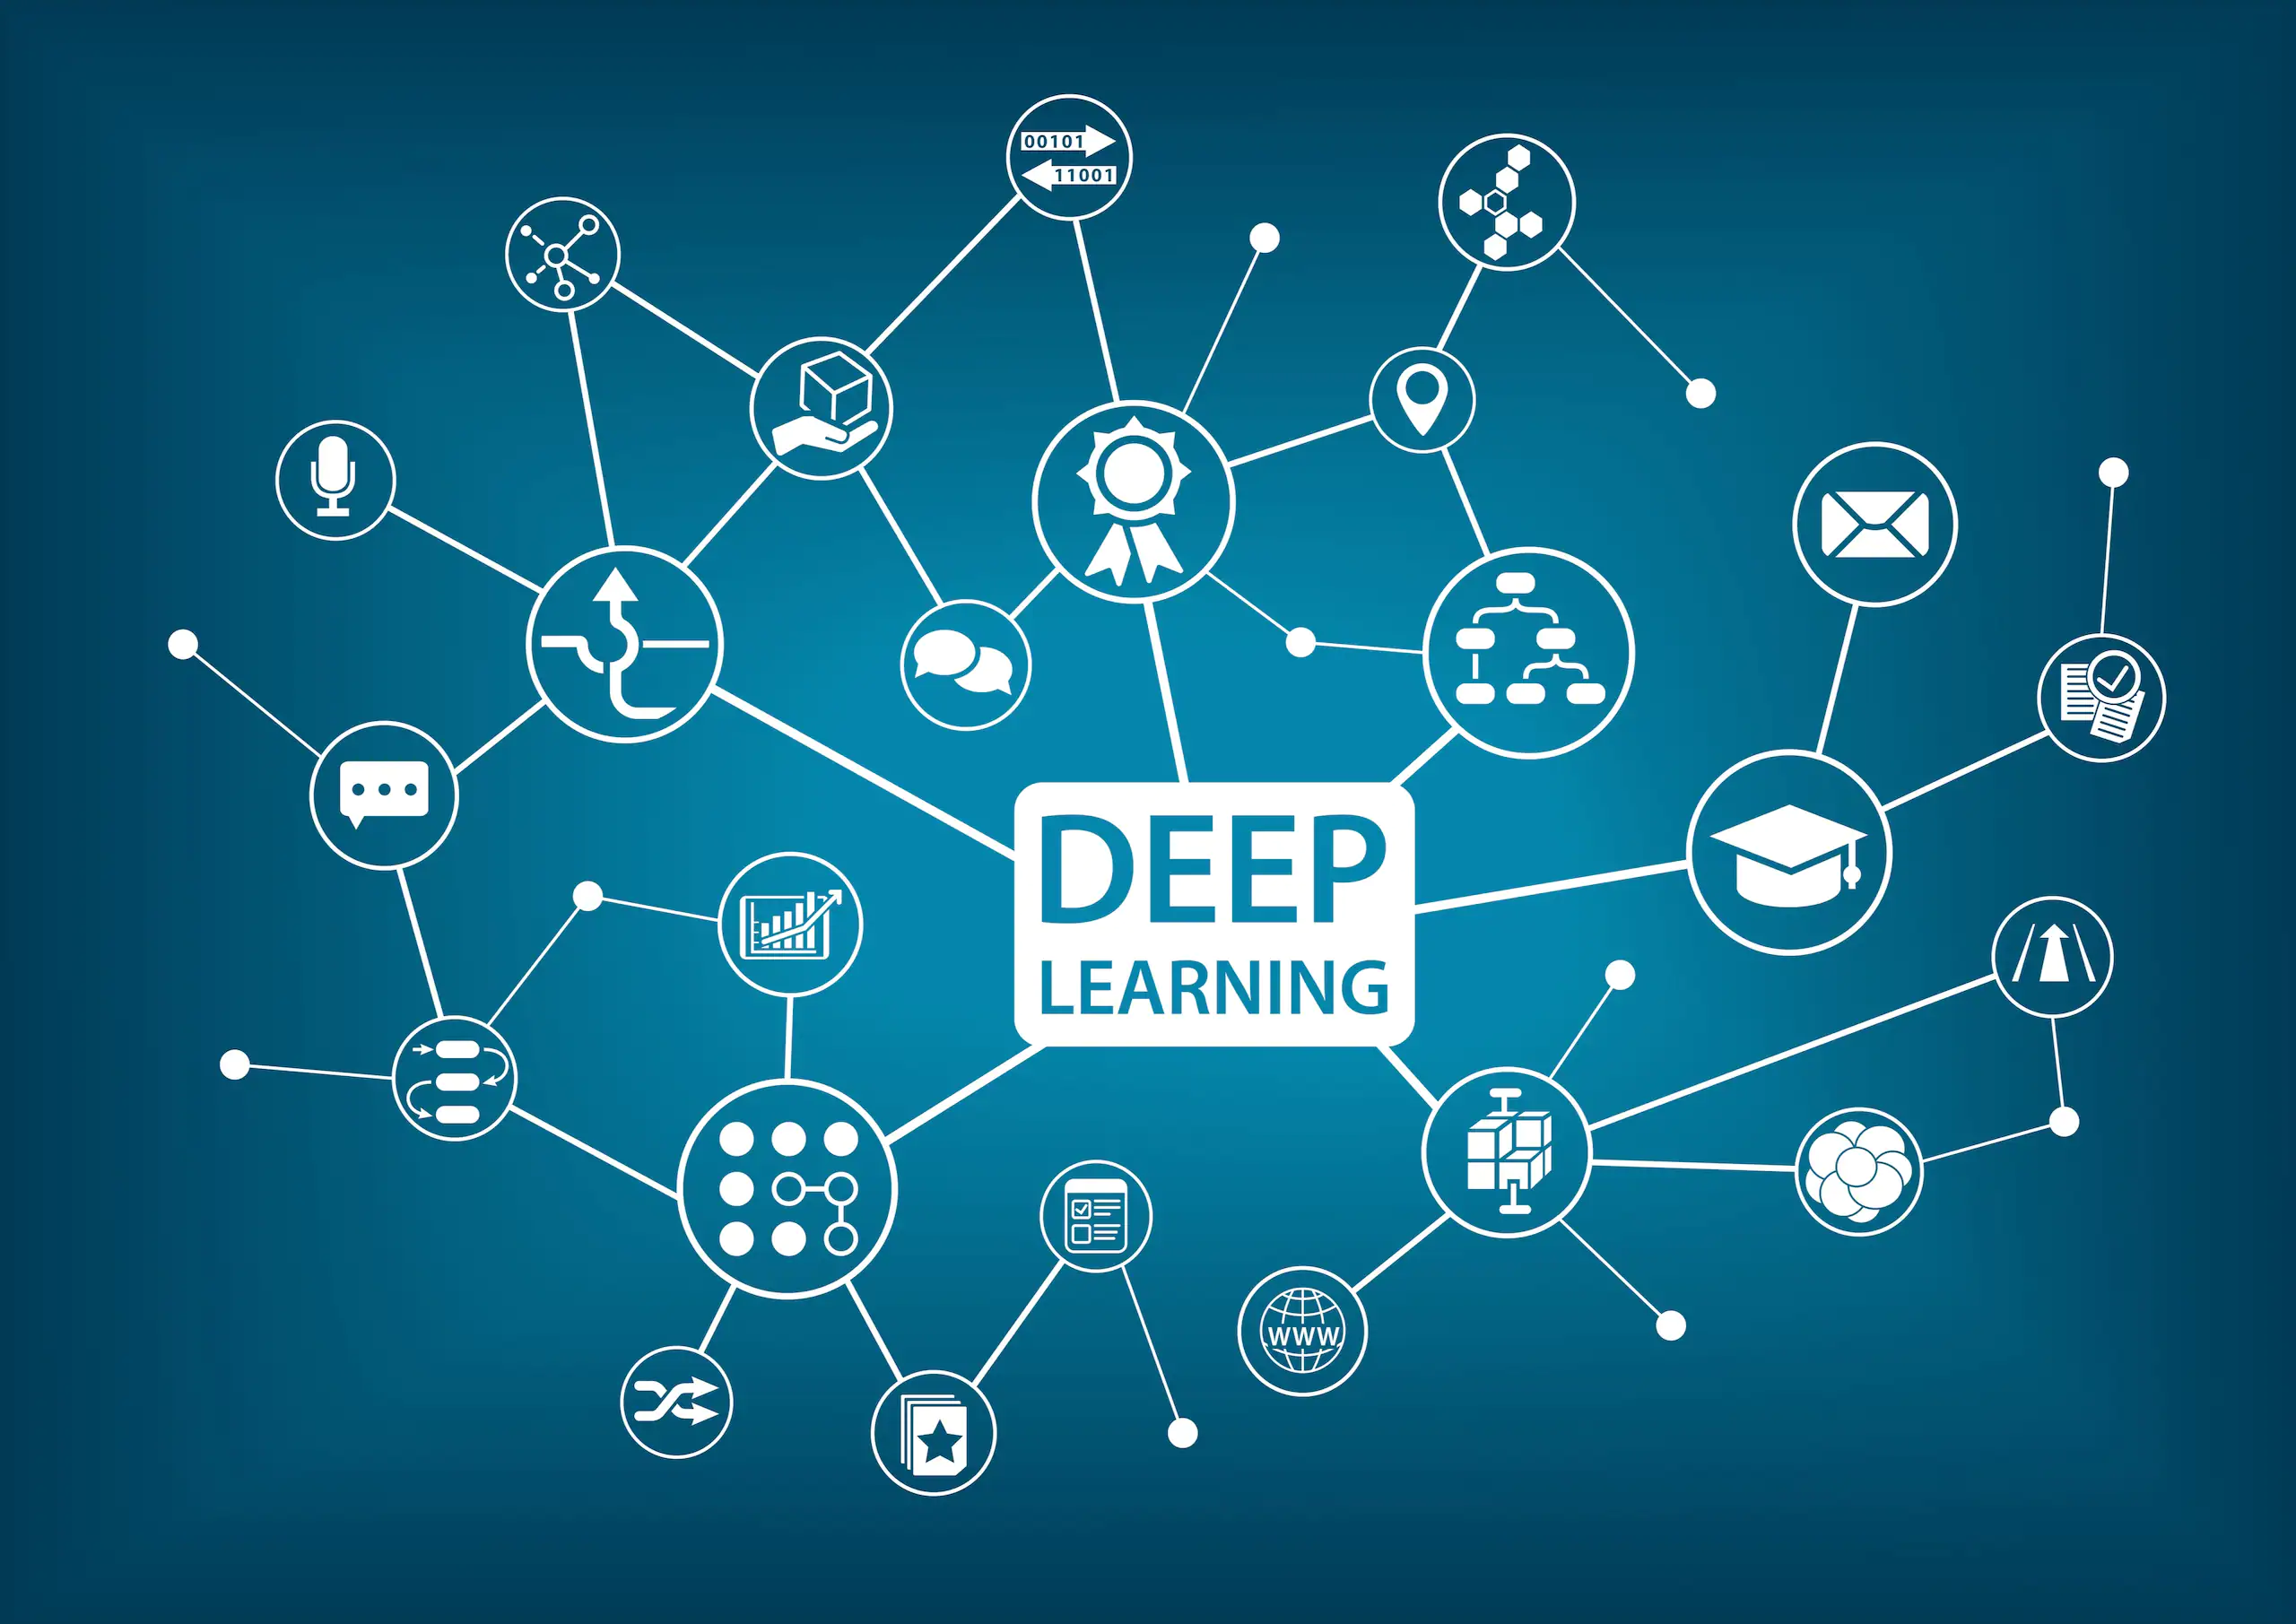

In [1]:
# Importing Neccessary Libraries
import shutil
from sklearn.model_selection import train_test_split
from google.colab import files
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from PIL import Image
from torchvision import transforms, models
import torch
import torch.nn as nn
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

In [2]:
# ِAuthorize Google Drive for data folders
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = "/content/drive/MyDrive/SkinDisease/SkinDisease"
TRAIN_FOLDER = DATA_ROOT + "/train"
TEST_FOLDER  = DATA_ROOT + "/test"
ALLOWED_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
def collect_samples(folder_path):
    class_names = [c for c in sorted(os.listdir(folder_path)) if os.path.isdir(folder_path + "/" + c)]
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    samples = []
    for cls in class_names:
        cls_path = folder_path + "/" + cls
        files = []
        for ext in ALLOWED_EXT:
            files.extend(glob.glob(cls_path + "/*" + ext))
            files.extend(glob.glob(cls_path + "/*" + ext.upper()))
        for f in files:
            samples.append((f, class_to_idx[cls]))
    return samples, class_names, class_to_idx
samples_train, class_names_train, class_to_idx_train = collect_samples(TRAIN_FOLDER)
samples_test,  class_names_test,  class_to_idx_test  = collect_samples(TEST_FOLDER)
all_samples = samples_train + samples_test
print("Total images collected:", len(all_samples))
print("Classes found (train folder):", len(class_names_train))
print("Classes found (test folder):", len(class_names_test))
paths  = [p for (p, y) in all_samples]
labels = [y for (p, y) in all_samples]
# First split: Train+Val vs Test
X_temp, X_test, y_temp, y_test = train_test_split(
    paths,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)
# Second split: Train vs Val (Val is 20% of X_temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    stratify=y_temp
)
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

class SkinDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label
# Preprocessing / Augmentation
IMG_SIZE = 224
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
# Dataset objects
train_dataset = SkinDiseaseDataset(X_train, y_train, transform=train_transform)
val_dataset   = SkinDiseaseDataset(X_val,   y_val,   transform=eval_transform)
test_dataset  = SkinDiseaseDataset(X_test,  y_test,  transform=eval_transform)
# Reduce the size of the dataset
import random
from torch.utils.data import Subset
# Seed for reproducibility
random.seed(42)
# Reduce datasets sizes
TRAIN_SIZE = 4000
VAL_SIZE   = 2000
TEST_SIZE  = 1000
# Ensure we don't take more than the dataset length
TRAIN_SIZE = min(TRAIN_SIZE, len(X_train))
VAL_SIZE   = min(VAL_SIZE, len(X_val))
TEST_SIZE  = min(TEST_SIZE, len(X_test))
# Get random indices
train_indices = random.sample(range(len(X_train)), TRAIN_SIZE)
val_indices   = random.sample(range(len(X_val)), VAL_SIZE)
test_indices  = random.sample(range(len(X_test)), TEST_SIZE)
# Create reduced datasets using Subset
train_dataset_small = Subset(train_dataset, train_indices)
val_dataset_small   = Subset(val_dataset, val_indices)
test_dataset_small  = Subset(test_dataset, test_indices)
#  DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset_small, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset_small,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset_small,  batch_size=BATCH_SIZE, shuffle=False)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total images collected: 15439
Classes found (train folder): 22
Classes found (test folder): 22
Train: 9880
Validation: 2471
Test: 3088
Train batches: 63
Val batches: 32
Test batches: 16
Batch images shape: torch.Size([64, 3, 224, 224])
Batch labels shape: torch.Size([64])


**First Traditional Model: MLP Model**

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        for param in self.backbone.parameters():
            param.requires_grad = False
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

In [ ]:
NUM_CLASSES = 22
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleMLP(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 5
history_simple = []
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )
    history_simple.append((train_loss, train_acc, val_loss, val_acc))
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 76.8MB/s]


In [ ]:
# Refining the model by making hyperparameter tuning and regularization
class ImprovedMLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

In [ ]:
improved_model = ImprovedMLP(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    improved_model.parameters(), lr=0.0003, weight_decay=1e-4
)
EPOCHS = 10
best_val_acc = 0
best_model_state = None
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        improved_model, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc = evaluate(
        improved_model, val_loader, criterion, device
    )
    print(f"[Epoch {epoch+1}] "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = improved_model.state_dict()

NameError: name 'ImprovedMLP' is not defined

In [ ]:
# The best model for testing
improved_model.load_state_dict(best_model_state)
test_loss, test_acc = evaluate(
    improved_model, test_loader, criterion, device
)
print(f"TEST Accuracy: {test_acc:.4f}")

NameError: name 'improved_model' is not defined

**Second Traditional Model**

In [ ]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((8, 8))

        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)



In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        correct += (outputs.argmax(1) == y).sum().item()
        total += y.size(0)

    return loss_sum / total, 100 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)

            loss_sum += loss.item() * x.size(0)
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum / total, 100 * correct / total


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
EPOCHS = 5
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    print(f"CNN | Epoch [{epoch+1}/{EPOCHS}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")


CNN | Epoch [1/3]
  Train Loss: 1.4243 | Train Acc: 48.99%
  Val   Loss: 1.2114 | Val   Acc: 52.75%
CNN | Epoch [2/3]
  Train Loss: 1.1637 | Train Acc: 56.43%
  Val   Loss: 1.0670 | Val   Acc: 60.10%
CNN | Epoch [3/3]
  Train Loss: 1.1107 | Train Acc: 58.77%
  Val   Loss: 1.0322 | Val   Acc: 61.16%


In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))
        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [ ]:
model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.0003, weight_decay=1e-4
)
best_val_acc = 0
best_model_state = None
EPOCHS = 5
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    print(f"Improved CNN | Epoch [{epoch+1}/{EPOCHS}]")
    print(f"  Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

Improved CNN | Epoch [1/5]
  Train Acc: 50.75% | Val Acc: 60.39%
Improved CNN | Epoch [2/5]
  Train Acc: 60.05% | Val Acc: 58.45%
Improved CNN | Epoch [3/5]
  Train Acc: 59.83% | Val Acc: 62.80%
Improved CNN | Epoch [4/5]
  Train Acc: 62.44% | Val Acc: 65.31%
Improved CNN | Epoch [5/5]
  Train Acc: 62.32% | Val Acc: 65.89%


In [ ]:
model.load_state_dict(best_model_state)
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"FINAL TEST ACCURACY: {test_acc:.2f}%")

NameError: name 'model' is not defined

**First Modern Model: VGG**

In [ ]:
#Initilize VGG model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg = models.vgg16(pretrained=True)

NameError: name 'torch' is not defined

In [ ]:
#Adjust baseline
NUM_CLASSES = len(class_names_train)
vgg.classifier[6] = nn.Linear(4096, NUM_CLASSES)
vgg = vgg.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg.parameters(), lr=0.001)

In [ ]:
#Train baseline model (VGG)
EPOCHS = 5
best_val_acc = 0
best_state = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(vgg, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(vgg, val_loader, criterion)

    print(f"VGG | Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = vgg.state_dict()

NameError: name 'train_epoch' is not defined

In [ ]:
#Enhance model by applying hyperparameter tunning and regularization
for param in vgg.features.parameters():
    param.requires_grad = False
optimizer = torch.optim.Adam(
    vgg.classifier.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

NameError: name 'vgg' is not defined

In [ ]:
#Train Enhanced model of VGG
EPOCHS = 5
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(vgg, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(vgg, val_loader, criterion)
    print(f"Improved VGG | Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = vgg.state_dict()

NameError: name 'train_epoch' is not defined

In [ ]:
#Choose best VGG model and testing it on testing set of data
vgg.load_state_dict(best_state)
test_loss, test_acc = evaluate(vgg, test_loader, criterion)
print(f"VGG TEST ACCURACY: {test_acc:.2f}%")

NameError: name 'vgg' is not defined

**Second Modern Mode AlexNet model**

In [3]:
#Initialize the model of alexnet
# NUM_CLASSES
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(class_names_train)
alexnet = models.alexnet(pretrained=True)
alexnet.classifier[6] = nn.Linear(4096, NUM_CLASSES)
alexnet = alexnet.to(device)
import torch
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


CUDA available: True
Current device: cuda


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(alexnet.parameters(), lr=0.001)

In [5]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    avg_loss = total_loss / total
    acc = 100 * correct / total
    return avg_loss, acc
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    avg_loss = total_loss / total
    acc = 100 * correct / total
    return avg_loss, acc

In [6]:
#Train model of baseline (Alexnet)
EPOCHS = 5
best_val_acc = 0
best_state = None
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(alexnet, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(alexnet, val_loader, criterion)
    print(f"AlexNet | Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = alexnet.state_dict()

AlexNet | Epoch 1
Train Acc: 11.55% | Val Acc: 12.05%
AlexNet | Epoch 2
Train Acc: 10.35% | Val Acc: 12.05%
AlexNet | Epoch 3
Train Acc: 11.55% | Val Acc: 12.05%
AlexNet | Epoch 4
Train Acc: 11.55% | Val Acc: 12.05%
AlexNet | Epoch 5
Train Acc: 11.55% | Val Acc: 12.05%


In [ ]:
#Enhance alexnet model through apply hyperparameter tuning and regularization
for param in alexnet.features.parameters():
    param.requires_grad = False
optimizer = torch.optim.Adam(
    alexnet.classifier.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

In [ ]:
#Train enehanced model of alexnet
EPOCHS = 5
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(alexnet, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(alexnet, val_loader, criterion)
    print(f"Improved AlexNet | Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = alexnet.state_dict()

NameError: name 'train_epoch' is not defined

In [ ]:
#Choose best AlexNet model and testing it on testing set of data
alexnet.load_state_dict(best_state)
test_loss, test_acc = evaluate(alexnet, test_loader, criterion)
print(f"ALEXNET TEST ACCURACY: {test_acc:.2f}%")

NameError: name 'alexnet' is not defined

In [ ]:
dir = "/content/Saved_Models"
os.makedirs(dir, exist_ok=True)
if 'cnn_model' in globals():
    torch.save(CNNModel.state_dict(), f"{dir}/cnn_traditional_model.pth")
if 'mlp_model' in globals():
    torch.save(SimpleMLP.state_dict(), f"{dir}/mlp_traditional_model.pth")
if 'vgg' in globals():
    torch.save(vgg.state_dict(), f"{dir}/vgg_modern_model.pth")
if 'alexnet' in globals():
    torch.save(alexnet.state_dict(), f"{dir}/alexnet_modern_model.pth")
ZIP_file = "/content/saved_models.zip"
shutil.make_archive(ZIP_file.replace(".zip", ""), "zip", dir)
files.download(ZIP_file)

NameError: name 'os' is not defined

**Modern Deep Learning Architecture (VGG)**

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [6]:
num_classes = len(class_names_train)

vgg_model = models.vgg16(pretrained=True)



# Replace classifier
vgg_model.classifier[6] = nn.Linear(4096, num_classes)

vgg_model = vgg_model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 89.6MB/s]


In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, vgg_model.parameters()),
    lr=1e-4
)

In [10]:
def train_model(model, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        val_loss = val_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
              f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


In [11]:
train_model(vgg_model, train_loader, val_loader, epochs=10)


 17%|█▋        | 26/155 [19:32<1:36:59, 45.11s/it]


KeyboardInterrupt: 

In [ ]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

evaluate(vgg_model, test_loader)


In [7]:
import os, glob, random
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from collections import defaultdict

# -------------------------------
# Assume you already have:
# - train_loader, val_loader, test_loader
# - class_names_train
# -------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(class_names_train)
BATCH_SIZE = 64
EPOCHS = 10  # You can increase for better results

# -------------------------------
# 1️⃣ Baseline AlexNet Model
# -------------------------------
baseline_model = models.alexnet(pretrained=True)

# Replace classifier
baseline_model.classifier = nn.Sequential(
    nn.Linear(256 * 6 * 6, 1024),
    nn.ReLU(),
    nn.Linear(1024, NUM_CLASSES)
)
baseline_model = baseline_model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-4)  # baseline: no weight_decay

# -------------------------------
# Training & Evaluation Functions
# -------------------------------
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=10):
    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        val_acc, val_loss = evaluate_model(model, val_loader, criterion)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if scheduler:
            scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")

    print("Training complete. Best validation accuracy:", best_val_acc)

def evaluate_model(model, data_loader, criterion=None):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            if criterion:
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

    acc = running_corrects.double() / len(data_loader.dataset)
    avg_loss = running_loss / len(data_loader.dataset) if criterion else 0
    return acc, avg_loss

# -------------------------------
# 2️⃣ Train Baseline Model
# -------------------------------
print("=== Training Baseline AlexNet ===")
train_model(baseline_model, train_loader, val_loader, criterion, optimizer, epochs=EPOCHS)

# Load best model and test
baseline_model.load_state_dict(torch.load("best_model.pth"))
test_acc, test_loss = evaluate_model(baseline_model, test_loader, criterion)
print(f"Baseline Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# -------------------------------
# 3️⃣ Enhanced / Refined AlexNet
# -------------------------------
enhanced_model = models.alexnet(pretrained=True)

# Freeze feature layers optionally
for param in enhanced_model.features.parameters():
    param.requires_grad = True  # False to freeze

# Add improved classifier with Dropout + extra layer
enhanced_model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(256 * 6 * 6, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),
    nn.Linear(1024, 512),
    nn.ReLU(inplace=True),
    nn.Linear(512, NUM_CLASSES)
)
enhanced_model = enhanced_model.to(device)

# Loss and optimizer with L2 regularization
optimizer = optim.Adam(enhanced_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# -------------------------------
# Train Enhanced Model
# -------------------------------
print("=== Training Enhanced AlexNet ===")
train_model(enhanced_model, train_loader, val_loader, criterion, optimizer, scheduler=scheduler, epochs=EPOCHS)

# Load best enhanced model and test
enhanced_model.load_state_dict(torch.load("best_model.pth"))
test_acc, test_loss = evaluate_model(enhanced_model, test_loader, criterion)
print(f"Enhanced Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")




=== Training Baseline AlexNet ===


Epoch 1/10: 100%|██████████| 63/63 [00:49<00:00,  1.27it/s]


Epoch 1/10 | Train Loss: 2.2929 Acc: 0.3148 | Val Loss: 2.0173 Acc: 0.3830


Epoch 2/10: 100%|██████████| 63/63 [00:49<00:00,  1.28it/s]


Epoch 2/10 | Train Loss: 1.6733 Acc: 0.4835 | Val Loss: 1.8811 Acc: 0.4220


...

Epoch 8/10 | Train Loss: 1.2314 Acc: 0.6165 | Val Loss: 1.8787 Acc: 0.4715


Epoch 9/10: 100%|██████████| 63/63 [00:48<00:00,  1.29it/s]


Epoch 9/10 | Train Loss: 1.1436 Acc: 0.6478 | Val Loss: 1.7819 Acc: 0.5010


Epoch 10/10: 100%|██████████| 63/63 [00:48<00:00,  1.29it/s]


Epoch 10/10 | Train Loss: 1.0850 Acc: 0.6600 | Val Loss: 1.8108 Acc: 0.4960
Training complete. Best validation accuracy: tensor(0.5010, device='cuda:0', dtype=torch.float64)
Enhanced Test Accuracy: 0.4840 | Test Loss: 1.8087


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from collections import defaultdict
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(class_names_train)  # same as before
BATCH_SIZE = 64
EPOCHS = 10  # adjust as needed

# -------------------------------
# 1️⃣ Baseline VGG16
# -------------------------------
baseline_vgg = models.vgg16(pretrained=True)

# Replace classifier (VGG16 original classifier has 4096-4096-1000)
baseline_vgg.classifier = nn.Sequential(
    nn.Linear(25088, 1024),  # 25088 = 512*7*7 feature maps
    nn.ReLU(),
    nn.Linear(1024, NUM_CLASSES)
)
baseline_vgg = baseline_vgg.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_vgg.parameters(), lr=1e-4)  # baseline: no regularization

# -------------------------------
# Training & Evaluation functions
# (same as AlexNet code)
# -------------------------------
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=10):
    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        val_acc, val_loss = evaluate_model(model, val_loader, criterion)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if scheduler:
            scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_vgg_model.pth")

    print("Training complete. Best validation accuracy:", best_val_acc)

def evaluate_model(model, data_loader, criterion=None):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            if criterion:
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

    acc = running_corrects.double() / len(data_loader.dataset)
    avg_loss = running_loss / len(data_loader.dataset) if criterion else 0
    return acc, avg_loss

# -------------------------------
# 2️⃣ Train Baseline VGG16
# -------------------------------
print("=== Training Baseline VGG16 ===")
train_model(baseline_vgg, train_loader, val_loader, criterion, optimizer, epochs=EPOCHS)

baseline_vgg.load_state_dict(torch.load("best_vgg_model.pth"))
test_acc, test_loss = evaluate_model(baseline_vgg, test_loader, criterion)
print(f"Baseline VGG16 Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# -------------------------------
# 3️⃣ Enhanced / Refined VGG16
# -------------------------------
enhanced_vgg = models.vgg16(pretrained=True)

# Freeze features optionally
for param in enhanced_vgg.features.parameters():
    param.requires_grad = True  # False to freeze

# Improved classifier
enhanced_vgg.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(25088, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),
    nn.Linear(1024, 512),
    nn.ReLU(inplace=True),
    nn.Linear(512, NUM_CLASSES)
)
enhanced_vgg = enhanced_vgg.to(device)

optimizer = optim.Adam(enhanced_vgg.parameters(), lr=1e-4, weight_decay=1e-4)  # L2 regularization
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# -------------------------------
# Train Enhanced VGG16
# -------------------------------
print("=== Training Enhanced VGG16 ===")
train_model(enhanced_vgg, train_loader, val_loader, criterion, optimizer, scheduler=scheduler, epochs=EPOCHS)

enhanced_vgg.load_state_dict(torch.load("best_vgg_model.pth"))
test_acc, test_loss = evaluate_model(enhanced_vgg, test_loader, criterion)
print(f"Enhanced VGG16 Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(class_names_train)
BATCH_SIZE = 64
EPOCHS = 10

# -------------------------------
# 1️⃣ Baseline MLP
# -------------------------------
class BaselineMLP(nn.Module):
    def __init__(self, input_size=224*224*3, num_classes=NUM_CLASSES):
        super(BaselineMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        return self.model(x)

baseline_mlp = BaselineMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_mlp.parameters(), lr=1e-4)

# -------------------------------
# Training & Evaluation functions (same as before)
# -------------------------------
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=10):
    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        val_acc, val_loss = evaluate_model(model, val_loader, criterion)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if scheduler:
            scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_mlp_model.pth")

    print("Training complete. Best validation accuracy:", best_val_acc)

def evaluate_model(model, data_loader, criterion=None):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            if criterion:
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

    acc = running_corrects.double() / len(data_loader.dataset)
    avg_loss = running_loss / len(data_loader.dataset) if criterion else 0
    return acc, avg_loss

# -------------------------------
# 2️⃣ Train Baseline MLP
# -------------------------------
print("=== Training Baseline MLP ===")
train_model(baseline_mlp, train_loader, val_loader, criterion, optimizer, epochs=EPOCHS)

baseline_mlp.load_state_dict(torch.load("best_mlp_model.pth"))
test_acc, test_loss = evaluate_model(baseline_mlp, test_loader, criterion)
print(f"Baseline MLP Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# -------------------------------
# 3️⃣ Enhanced / Refined MLP
# -------------------------------
class EnhancedMLP(nn.Module):
    def __init__(self, input_size=224*224*3, num_classes=NUM_CLASSES):
        super(EnhancedMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 2048),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

enhanced_mlp = EnhancedMLP().to(device)
optimizer = optim.Adam(enhanced_mlp.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# -------------------------------
# Train Enhanced MLP
# -------------------------------
print("=== Training Enhanced MLP ===")
train_model(enhanced_mlp, train_loader, val_loader, criterion, optimizer, scheduler=scheduler, epochs=EPOCHS)

enhanced_mlp.load_state_dict(torch.load("best_mlp_model.pth"))
test_acc, test_loss = evaluate_model(enhanced_mlp, test_loader, criterion)
print(f"Enhanced MLP Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(class_names_train)
BATCH_SIZE = 64
EPOCHS = 10

# -------------------------------
# 1️⃣ Baseline CNN
# -------------------------------
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline_cnn = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_cnn.parameters(), lr=1e-4)

# -------------------------------
# 2️⃣ Enhanced CNN
# -------------------------------
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(EnhancedCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout(0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout(0.3),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout(0.4),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout(0.5)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*14*14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

enhanced_cnn = EnhancedCNN().to(device)
optimizer_enh = optim.Adam(enhanced_cnn.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_enh = optim.lr_scheduler.StepLR(optimizer_enh, step_size=5, gamma=0.5)

# -------------------------------
# 3️⃣ Training & Evaluation Functions
# -------------------------------
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=10):
    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        val_acc, val_loss = evaluate_model(model, val_loader, criterion)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if scheduler:
            scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_cnn_model.pth")

    print("Training complete. Best validation accuracy:", best_val_acc)

def evaluate_model(model, data_loader, criterion=None):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            if criterion:
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

    acc = running_corrects.double() / len(data_loader.dataset)
    avg_loss = running_loss / len(data_loader.dataset) if criterion else 0
    return acc, avg_loss



# -------------------------------
# 4️⃣ Train Baseline CNN
# -------------------------------
print("=== Training Baseline CNN ===")
train_model(baseline_cnn, train_loader, val_loader, criterion, optimizer, epochs=EPOCHS)

baseline_cnn.load_state_dict(torch.load("best_cnn_model.pth"))
test_acc, test_loss = evaluate_model(baseline_cnn, test_loader, criterion)
print(f"Baseline CNN Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# -------------------------------
# 5️⃣ Train Enhanced CNN
# -------------------------------
print("=== Training Enhanced CNN ===")
train_model(enhanced_cnn, train_loader, val_loader, criterion, optimizer_enh, scheduler=scheduler_enh, epochs=EPOCHS)

enhanced_cnn.load_state_dict(torch.load("best_cnn_model.pth"))
test_acc, test_loss = evaluate_model(enhanced_cnn, test_loader, criterion)
print(f"Enhanced CNN Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


